### DSA2025 第14講：講義資料【単回帰・重回帰分析】

参考資料：[重回帰分析とは？概要から分析の流れまでわかりやすく解説](https://data-viz-lab.com/multiple-regression-analysis)

Pythonを用いた回帰には様々な方法があるが、今回はstatsmodels を用いる。データを一度、Pandasのdataframeに変換する必要がある。  
ここでは 最小二乗法を扱う ols を利用する。　詳細は例えば [こちら](https://qiita.com/innovation1005/items/b712ce54a7a697a9bf03)  
また、
+ statsmodels.api
+ statsmodels.formula.api  
の2通りあるが、ここでは下のformula付を用いる。この場合、y切片を defaultで持つので、statsmodels.api のように add_constant は不要。

In [1]:
# 必要なライブラリのインストール
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# グラフをinline表示可能にする
%matplotlib inline

# 解像度を上げてinline表示する
%config InlineBackend.figure_format = 'retina'

# 日本語表示用ライブラリ（matplotlibで日本語を使用したい場合）
try:
    import japanize_matplotlib
except ModuleNotFoundError:
    # 初回だけインストールするので時間がかかる
    !pip install japanize-matplotlib
    import japanize_matplotlib

In [2]:
# pairplot 作成用ライブラリ読み込み
import seaborn as sns

# ネット情報取得用ライブラリ読み込み
import urllib.request

# 回帰用ライブラリ
try:
    from statsmodels.formula.api import ols
except ModuleNotFoundError:
    # 初回だけインストールするので時間がかかる
    !pip install statsmodels
    from statsmodels.formula.api import ols

# 計量経済分析用データセット
try:
    import wooldridge
except ModuleNotFoundError:
    # 初回だけインストールするので時間がかかる
    !pip install wooldridge
    import wooldridge

#### 回帰曲線（直線）の作成＆描画

In [3]:
# データ準備（データサイエンス概説テキスト p. 141）
shoe_size = np.array([24.5, 28.0, 26.0, 25.5, 25.0, 24.0])
height = np.array([165.4, 182.7, 171.6, 173.1, 175.1, 170.6])

# データを dataframe に格納
df_height = pd.DataFrame({'shoe_size': shoe_size, 'height': height})
df_height.head()

,shoe_size,height
0,24.5,165.4
1,28.0,182.7
2,26.0,171.6
3,25.5,173.1
4,25.0,175.1


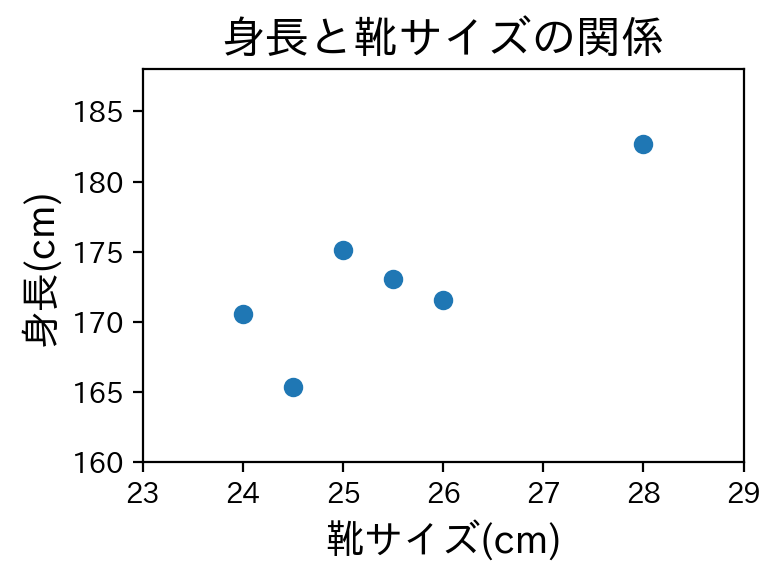

In [4]:
# 散布図の作成
plt.figure(figsize=(4,3))
plt.scatter(df_height['shoe_size'], df_height['height'])  # plt.scatter(shoe_size, height) でもよい

# 諸設定
plt.xlim([23,29])
plt.ylim([160,188])
plt.title("身長と靴サイズの関係", fontsize=16)
plt.xlabel('靴サイズ(cm)', fontsize=14)
plt.ylabel('身長(cm)', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# 線形回帰（１次式）：fitting実行
res = ols("height ~ shoe_size", data=df_height).fit()

# resが持つ method 
print(dir(res))

['HC0_se', 'HC1_se', 'HC2_se', 'HC3_se', '_HCCM', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_abat_diagonal', '_cache', '_data_attr', '_data_in_cache', '_get_robustcov_results', '_get_wald_nonlinear', '_is_nested', '_transform_predict_exog', '_use_t', '_wexog_singular_values', 'aic', 'bic', 'bse', 'centered_tss', 'compare_f_test', 'compare_lm_test', 'compare_lr_test', 'condition_number', 'conf_int', 'conf_int_el', 'cov_HC0', 'cov_HC1', 'cov_HC2', 'cov_HC3', 'cov_kwds', 'cov_params', 'cov_type', 'df_model', 'df_resid', 'eigenvals', 'el_test', 'ess', 'f_pvalue', 'f_test', 'fittedvalues', 'fvalue', 'get_influence', 'get_prediction', 

In [6]:
res.summary()

C:\Users\hkuma\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 height   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     9.017
Date:                Mon, 24 Nov 2025   Prob (F-statistic):             0.0398
Time:                        16:33:07   Log-Likelihood:                -14.897
No. Observations:                   6   AIC:                             33.79
Df Residuals:                       4   BIC:                             33.38
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     87.1483     28.654      3.041      0.038       7.591     166.706
shoe_size      3.3700      1.122      3.003      0.040       0.254       6.486
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   1.475
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.569
Skew:                          -0.292   Prob(JB):                        0.752
Kurtosis:                       1.609   Cond. No.                         506.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### fitting 結果
[【初心者脱出】statsmodelsによる重回帰分析結果の見方](https://self-development.info/%E3%80%90%E5%88%9D%E5%BF%83%E8%80%85%E8%84%B1%E5%87%BA%E3%80%91statsmodels%E3%81%AB%E3%82%88%E3%82%8B%E9%87%8D%E5%9B%9E%E5%B8%B0%E5%88%86%E6%9E%90%E7%B5%90%E6%9E%9C%E3%81%AE%E8%A6%8B%E6%96%B9/)

In [7]:
res.summary()

C:\Users\hkuma\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 height   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     9.017
Date:                Mon, 24 Nov 2025   Prob (F-statistic):             0.0398
Time:                        16:33:07   Log-Likelihood:                -14.897
No. Observations:                   6   AIC:                             33.79
Df Residuals:                       4   BIC:                             33.38
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     87.1483     28.654      3.041      0.038       7.591     166.706
shoe_size      3.3700      1.122      3.003      0.040       0.254       6.486
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   1.475
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.569
Skew:                          -0.292   Prob(JB):                        0.752
Kurtosis:                       1.609   Cond. No.                         506.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
# 予測値（回帰直線）の取得
print(res.predict())

[169.71333333 181.50833333 174.76833333 173.08333333 171.39833333
 168.02833333]


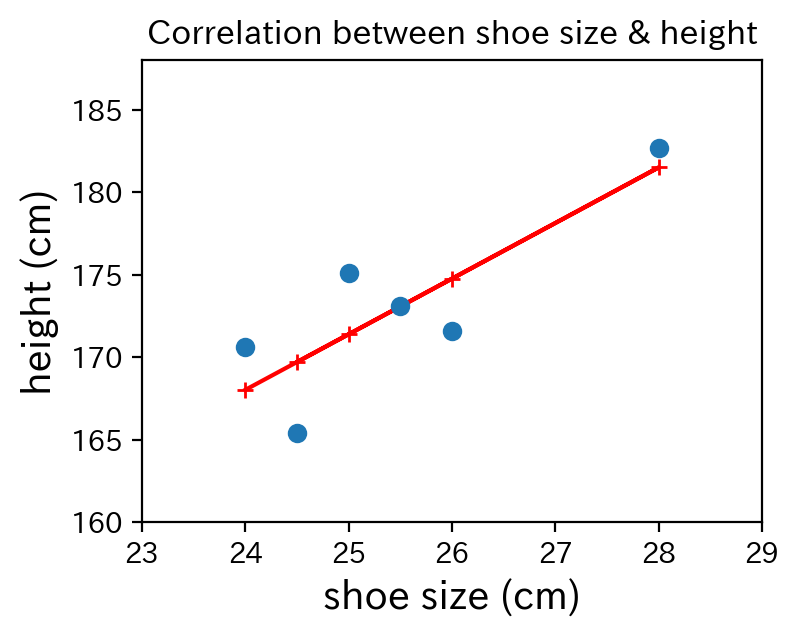

In [9]:
# 散布図の作成
plt.figure(figsize=(4,3))
plt.scatter(df_height['shoe_size'], df_height['height'], zorder=2)  # plt.scatter(shoe_size, height) でもよい

# 回帰直線 (res.predict) の描画
plt.plot(df_height['shoe_size'], res.predict(), 'r+-', zorder=1)

# 諸設定
plt.xlim([23,29])
plt.ylim([160,188])
plt.title("Correlation between shoe size & height")
plt.xlabel('shoe size (cm)', fontsize=14)
plt.ylabel('height (cm)', fontsize=14)
plt.show()

In [10]:
# excelファイルの読み込み
df_ice = pd.read_excel('https://ccs-kumanolab.com/lecture/dsa/ice_tea__temp.xlsx')

# 最初の5件表示
df_ice.head()

,気温,アイス売上,お茶売上
0,25.8,2570,6897
1,24.4,2369,6172
2,22.0,2295,5721
3,24.1,2289,5828
4,25.7,2561,6810


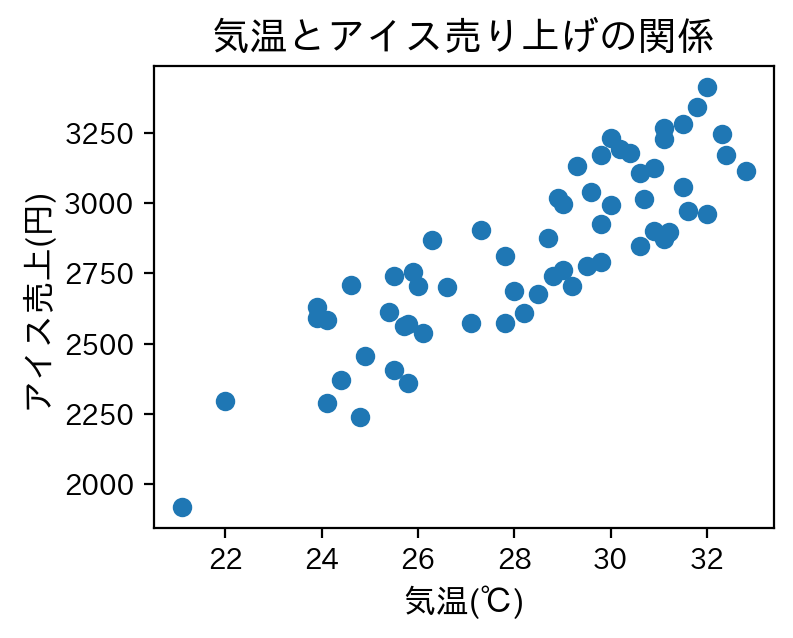

In [11]:
# 散布図の作成
plt.figure(figsize=(4,3))
plt.scatter(df_ice['気温'], df_ice['アイス売上'])

# 諸設定
plt.title("気温とアイス売り上げの関係", fontsize=14)
plt.xlabel('気温(℃)', fontsize=12)
plt.ylabel('アイス売上(円)', fontsize=12)
plt.show()

In [12]:
# 単回帰（線形回帰）
res = ols("アイス売上 ~ 気温", data=df_ice).fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  アイス売上   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     173.9
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           2.23e-19
Time:                        16:33:09   Log-Likelihood:                -400.91
No. Observations:                  62   AIC:                             805.8
Df Residuals:                      60   BIC:                             810.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    184.3545    201.175      0.916      0.363    -218.055     586.764
気温            93.2321      7.071     13.186      0.000      79.089     107.376
==============================================================================
Omnibus:                       41.725   Durbin-Watson:                   2.611
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                5.161
Skew:                           0.028   Prob(JB):                       0.0757
Kurtosis:                       1.588   Cond. No.                         285.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
a = res.params['気温']
b = res.params['Intercept']
a, b

(np.float64(93.23212103713712), np.float64(184.35453476801672))

In [14]:
# 回帰(regression)直線の準備
y_reg = (lambda x: a*x + b)(df_ice['気温'])
print(y_reg)

0     2589.743258
1     2459.218288
2     2235.461198
3     2431.248652
4     2580.420045
         ...     
57    2860.116409
58    2916.055681
59    3018.611014
60    3046.580651
61    3083.873499
Name: 気温, Length: 62, dtype: float64


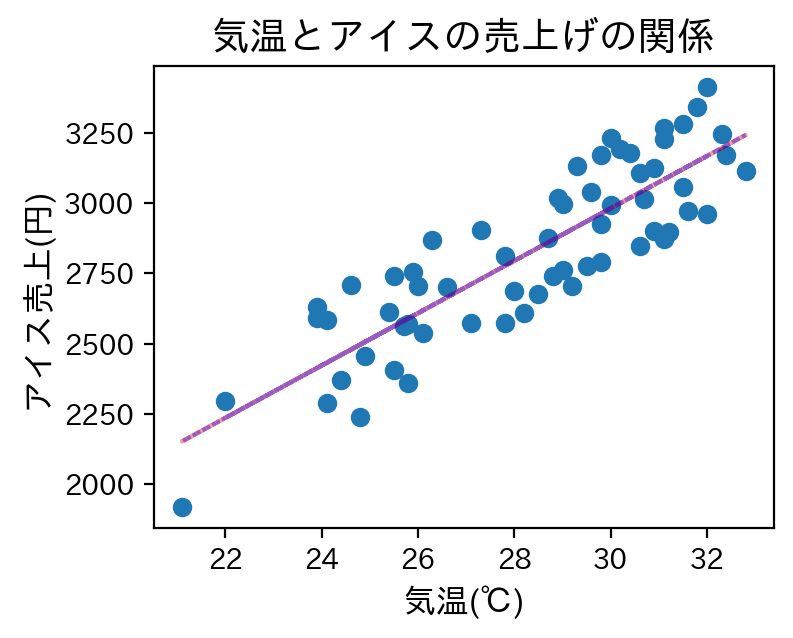

In [15]:
# 散布図の作成
plt.figure(figsize=(4,3))
plt.scatter(df_ice['気温'], df_ice['アイス売上'])

# predictの値を使った回帰直線描画
plt.plot(df_ice['気温'], res.predict(), 'r-', alpha=0.4)

# 傾きと切片の値を使った回帰直線描画
plt.plot(df_ice['気温'], y_reg, 'b:', alpha=0.4)

# 諸設定
plt.title("気温とアイスの売上げの関係", fontsize=14)
plt.xlabel('気温(℃)', fontsize=12)
plt.ylabel('アイス売上(円)', fontsize=12)
plt.show()

In [16]:
# 予測値
kion = 29
y = (lambda x: a*x + b)(kion)
print(y)

2888.086044844993


In [17]:
# f文字列
print(f'気温が {kion}℃ の日の売上げ予測は、{(lambda x: a*x + b)(kion)}円です。')

気温が 29℃ の日の売上げ予測は、2888.086044844993円です。


In [18]:
# f文字列
print(f'気温が{kion}℃の日の売り上げ予測は、{(lambda x: a*x + b)(kion):,.0f}円です。')

気温が29℃の日の売り上げ予測は、2,888円です。


### お茶の売上げについて、アイスと同様の処理を行ってみよ。

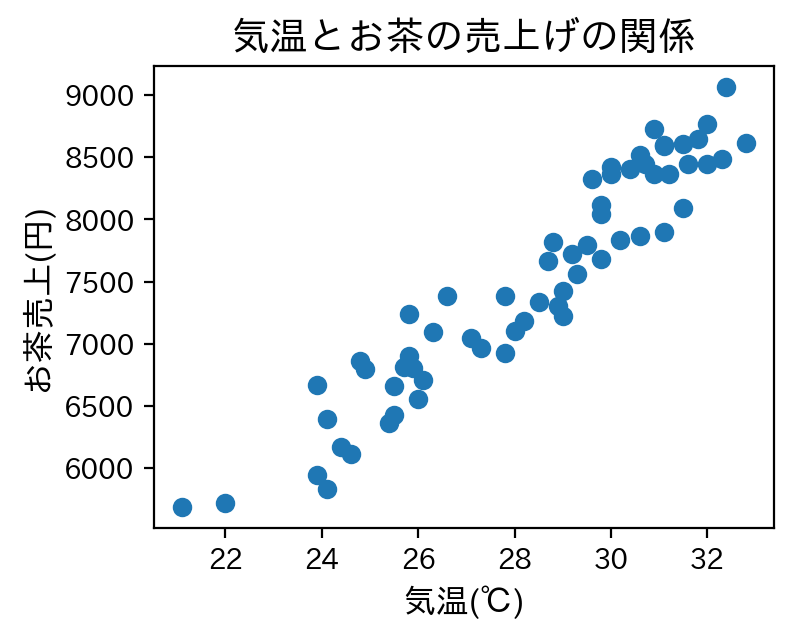

In [19]:
# 散布図の作成
plt.figure(figsize=(4,3))
plt.scatter(df_ice['気温'], df_ice['お茶売上'])

# 諸設定
plt.title("気温とお茶の売上げの関係", fontsize=14)
plt.xlabel('気温(℃)', fontsize=12)
plt.ylabel('お茶売上(円)', fontsize=12)
plt.show()

In [20]:
# 単回帰（線形回帰）
res = ols("お茶売上 ~ 気温", data=df_ice).fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   お茶売上   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     568.3
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           2.70e-32
Time:                        16:33:09   Log-Likelihood:                -435.83
No. Observations:                  62   AIC:                             875.7
Df Residuals:                      60   BIC:                             879.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -875.5185    353.317     -2.478      0.016   -1582.259    -168.778
気温           296.0324     12.418     23.839      0.000     271.193     320.872
==============================================================================
Omnibus:                       17.105   Durbin-Watson:                   1.843
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                3.859
Skew:                           0.087   Prob(JB):                        0.145
Kurtosis:                       1.790   Cond. No.                         285.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [21]:
a = res.params['気温']
b = res.params['Intercept']

In [22]:
# 回帰(regression)直線の準備
y_reg = (lambda x: a*x + b)(df_ice['気温'])
print(y_reg)

0     6762.118573
1     6347.673149
2     5637.195280
3     6258.863416
4     6732.515328
         ...     
57    7620.612664
58    7798.232131
59    8123.867821
60    8212.677555
61    8331.090533
Name: 気温, Length: 62, dtype: float64


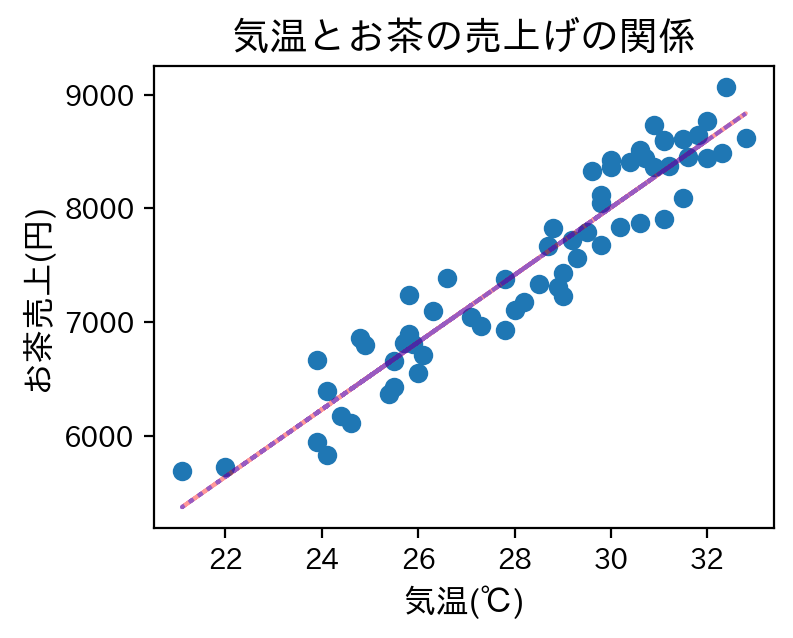

In [23]:
# 散布図の作成
plt.figure(figsize=(4,3))
plt.scatter(df_ice['気温'], df_ice['お茶売上'])

# predictの値を使った回帰直線描画
plt.plot(df_ice['気温'], res.predict(), 'r-', alpha=0.4)

# 傾きと切片の値を使った回帰直線描画
plt.plot(df_ice['気温'], y_reg, 'b:', alpha=0.4)

# 諸設定
plt.title("気温とお茶の売上げの関係", fontsize=14)
plt.xlabel('気温(℃)', fontsize=12)
plt.ylabel('お茶売上(円)', fontsize=12)
plt.show()

In [24]:
# 予測値
kion = 29
y = (lambda x: a*x + b)(kion)
print(y)

7709.422397747952


In [25]:
# f文字列
print(f'気温が {kion}℃ の日の売上げ予測は、{(lambda x: a*x + b)(kion)}円です。')

気温が 29℃ の日の売上げ予測は、7709.422397747952円です。


In [26]:
# f文字列
print(f'気温が {kion}℃ の日の売上げ予測は、{(lambda x: a*x + b)(kion):,.0f}円です。')

気温が 29℃ の日の売上げ予測は、7,709円です。


#### 回帰曲線の作成＆描画（多項式へのfitting）

In [27]:
np.random.seed(100)
x = np.arange(-10,11)

# 多項式 y = x^3 + x +2 の x の係数に乱数でノイズを加える
noise=np.random.normal(0, 1, 21)
y = x**3 + (1 + noise*10) * x + 2

# データを dataframe に格納
df = pd.DataFrame({'xdata': x, 'ydata': y})
df.head()

,xdata,ydata
0,-10,-833.023453
1,-9,-766.841236
2,-8,-610.242864
3,-7,-330.329477
4,-6,-278.879247


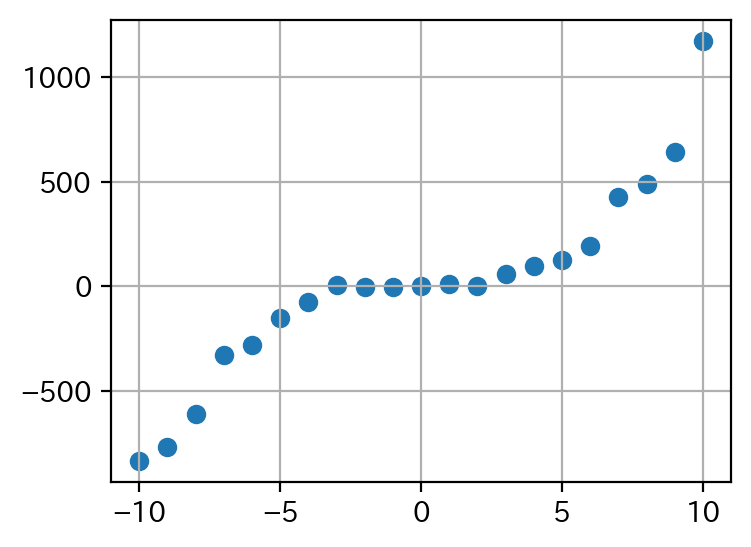

In [28]:
plt.figure(figsize=(4,3))

# 散布図
# plt.scatter(df[xdata], df['ydata']) に同じ
plt.scatter(df.xdata, df.ydata)
plt.grid()
plt.show()

In [29]:
# 線形回帰（１次式）
res = ols("ydata ~ xdata", data=df).fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  ydata   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     103.1
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           4.10e-09
Time:                        16:33:10   Log-Likelihood:                -138.27
No. Observations:                  21   AIC:                             280.5
Df Residuals:                      19   BIC:                             282.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.4640     40.169      0.186      0.855     -76.611      91.539
xdata         67.3715      6.634     10.156      0.000      53.487      81.256
==============================================================================
Omnibus:                        5.245   Durbin-Watson:                   0.521
Prob(Omnibus):                  0.073   Jarque-Bera (JB):                3.205
Skew:                           0.904   Prob(JB):                        0.201
Kurtosis:                       3.630   Cond. No.                         6.06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

[-666.25086063 -598.87937763 -531.50789464 -464.13641164 -396.76492864
 -329.39344565 -262.02196265 -194.65047966 -127.27899666  -59.90751367
    7.46396933   74.83545232  142.20693532  209.57841832  276.94990131
  344.32138431  411.6928673   479.0643503   546.43583329  613.80731629
  681.17879929]


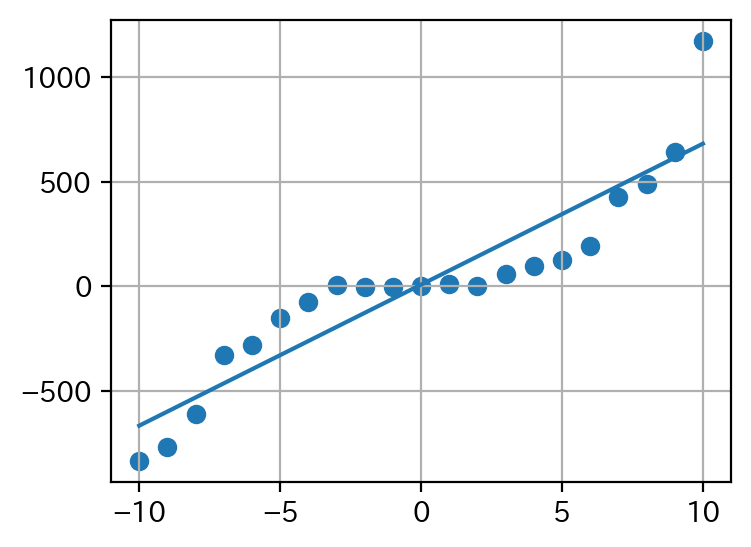

In [30]:
# 可視化
plt.figure(figsize=(4,3))
plt.scatter(x, y)
plt.plot(df.xdata, res.predict())
plt.grid()
print(res.predict())
plt.show()

In [31]:
# 多項式（ここでは３次式）で回帰

# res = ols("ydata ~ I(xdata**1) + I(xdata**2) + I(xdata**3)", data=df).fit() と同じ
res = ols("ydata ~ x + I(xdata**2) + I(xdata**3)", data=df).fit()

# 各種統計情報の表示
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  ydata   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     280.6
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           1.13e-14
Time:                        16:33:10   Log-Likelihood:                -116.62
No. Observations:                  21   AIC:                             241.2
Df Residuals:                      17   BIC:                             245.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       -11.8377     22.765     -0.520      0.610     -59.868      36.192
x                 5.2278      6.304      0.829      0.418      -8.074      18.529
I(xdata ** 2)     0.5264      0.463      1.136      0.272      -0.451       1.504
I(xdata ** 3)     0.9444      0.088     10.739      0.000       0.759       1.130
==============================================================================
Omnibus:                        0.765   Durbin-Watson:                   1.956
Prob(Omnibus):                  0.682   Jarque-Bera (JB):                0.100
Skew:                           0.140   Prob(JB):                        0.951
Kurtosis:                       3.190   Cond. No.                         652.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

[-955.90779424 -704.74035246 -503.51949961 -346.5786346  -228.25115635
 -142.87046375  -84.76995571  -48.28303114  -27.74308895  -17.48352804
  -11.83774731   -5.13914568    8.27887796   34.08292469   77.93959561
  145.51549182  242.4772144   374.49136445  547.22454307  766.34335135
 1037.51439039]


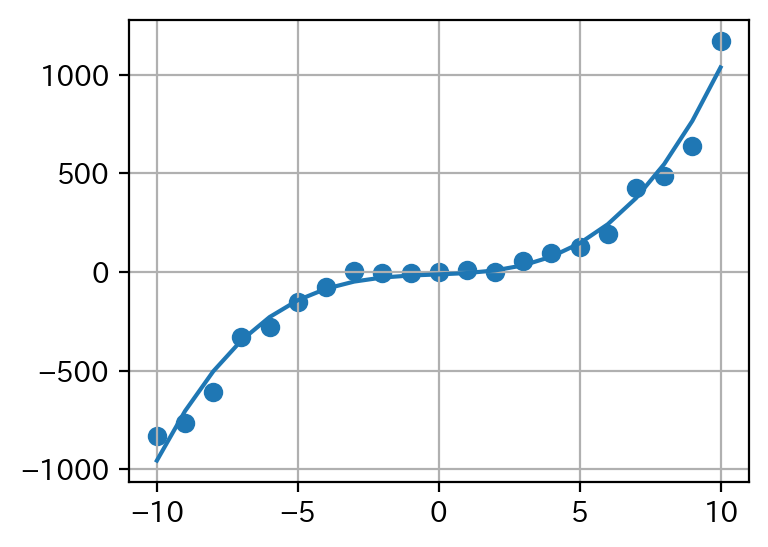

In [32]:
print(res.predict())

plt.figure(figsize=(4,3))
plt.scatter(x, y)
plt.plot(df.xdata, res.predict())
plt.grid()
plt.show()

#### 回帰分析（重回帰）：家賃を決める要素を説明してみる
[連載！データ分析②：回帰分析](https://www.asakonet.co.jp/asunomikata/contents/1782/20250214_watanabe-akira_2_regression/)  
【データ出典】 [データ分析学習環境「Connect DB」](https://cdb.eplang.jp/)  

In [33]:
# excelファイルの読み込み
df_rent = pd.read_excel('https://ccs-kumanolab.com/lecture/dsa/rent_mreg.xlsx')

# 最初の5件表示
df_rent.head()

,家賃,駅徒歩,築年数,面積,階
0,27000,14,32,15.84,1
1,28000,15,30,19.87,2
2,29000,15,35,17.79,2
3,30000,15,46,28.00,2
4,31000,10,38,19.87,1


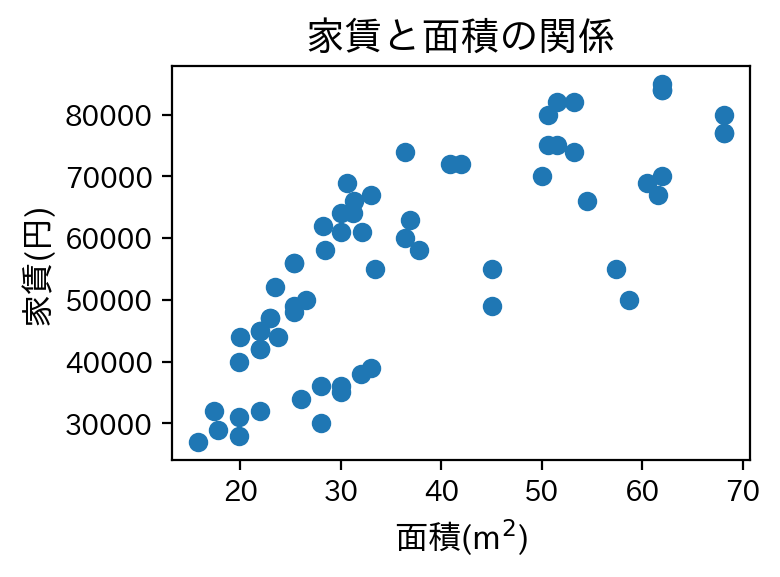

In [34]:
# 散布図の作成
plt.figure(figsize=(4,3))
plt.scatter(df_rent['面積'], df_rent['家賃'])  # plt.scatter(shoe_size, height) でもよい

# 諸設定
plt.title("家賃と面積の関係", fontsize=14)

# 上付き文字
plt.xlabel('面積(m$^2$)', fontsize=12)
plt.ylabel('家賃(円)', fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
# 単回帰（線形回帰）
res = ols("家賃 ~ 面積", data=df_rent).fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     家賃   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     97.55
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           2.03e-14
Time:                        16:33:11   Log-Likelihood:                -693.36
No. Observations:                  65   AIC:                             1391.
Df Residuals:                      63   BIC:                             1395.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    2.51e+04   3428.587      7.321      0.000    1.82e+04     3.2e+04
面積           846.7119     85.728      9.877      0.000     675.399    1018.025
==============================================================================
Omnibus:                        6.192   Durbin-Watson:                   1.152
Prob(Omnibus):                  0.045   Jarque-Bera (JB):                3.074
Skew:                          -0.280   Prob(JB):                        0.215
Kurtosis:                       2.094   Cond. No.                         105.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [36]:
# 予測値の取得
print(res.predict())

[38511.06181198 41923.31076038 40162.15001282 48807.07849004
 41923.31076038 39823.46525367 43726.80710284 47113.6546943
 50500.50228577 48807.07849004 50500.50228577 52193.9260815
 53040.63797937 41923.31076038 43726.80710284 43726.80710284
 45183.15156717 42033.3833071  43726.80710284 43726.80710284
 44573.5190007  44573.5190007  46537.89060375 46537.89060375
 63201.18075377 47553.94488119 74801.13375455 44996.87494964
 53370.85561954 63201.18075377 73717.34252528 46537.89060375
 46537.89060375 49145.76324918 57104.85508913 55919.45843212
 52278.59727129 50500.50228577 49027.22358348 56359.74861901
 51508.08944423 50500.50228577 51575.82639606 71202.60818861
 53023.70374141 77222.72978245 51042.39790041 76325.21517071
 77595.28301751 67434.74024311 59729.66197252 60661.04506017
 55877.12283723 70144.21831628 68687.87385195 67993.5700957
 82768.69271347 82768.69271347 67993.5700957  82768.69271347
 68687.87385195 70144.21831628 77595.28301751 77595.28301751
 77595.28301751]


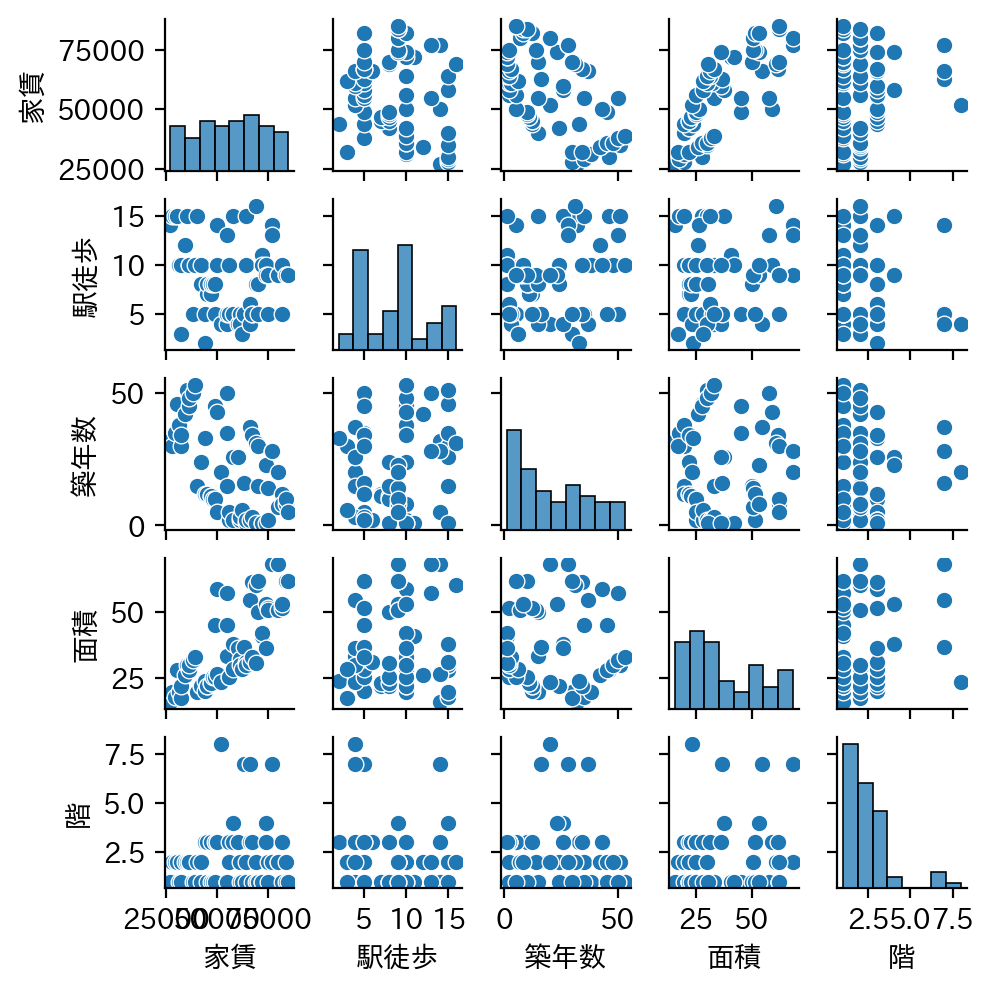

In [37]:
# pairplot 作成
sns.pairplot(df_rent, height=1)
plt.show()

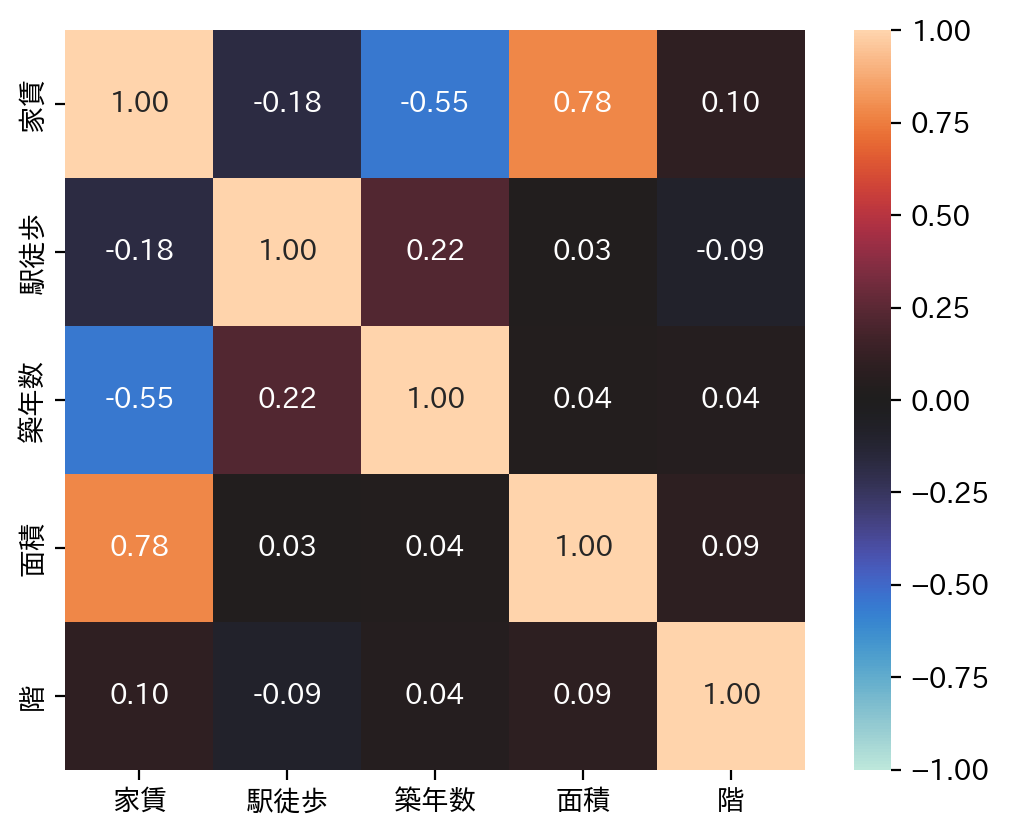

In [38]:
# ヒートマップ作成
sns.heatmap(df_rent.corr(numeric_only=True), annot=True, square=True, vmax=1, vmin=-1, center=0, fmt='.2f')
plt.show()

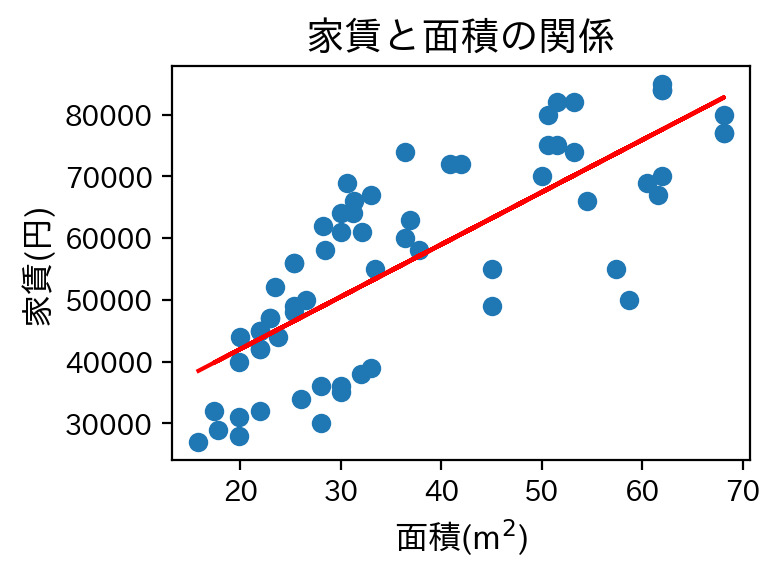

In [39]:
# 散布図の作成
plt.figure(figsize=(4,3))
plt.scatter(df_rent['面積'], df_rent['家賃'])
plt.plot(df_rent['面積'], res.predict(), 'r-')

# 諸設定
plt.title("家賃と面積の関係", fontsize=14)
plt.xlabel('面積(m$^2$)', fontsize=12)
plt.ylabel('家賃(円)', fontsize=12)
plt.tight_layout()
plt.show()

#### 重回帰：家賃を説明するのに、面積以外の要因も考慮する

In [40]:
df_rent.head()

,家賃,駅徒歩,築年数,面積,階
0,27000,14,32,15.84,1
1,28000,15,30,19.87,2
2,29000,15,35,17.79,2
3,30000,15,46,28.00,2
4,31000,10,38,19.87,1


In [41]:
# 重回帰
res = ols("家賃 ~ 駅徒歩 + 築年数 + 面積 + 階", data=df_rent).fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     家賃   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     292.7
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           1.28e-38
Time:                        16:33:16   Log-Likelihood:                -625.57
No. Observations:                  65   AIC:                             1261.
Df Residuals:                      60   BIC:                             1272.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.803e+04   1792.915     21.211      0.000    3.44e+04    4.16e+04
駅徒歩         -309.8782    130.714     -2.371      0.021    -571.346     -48.411
築年数         -589.6999     30.500    -19.335      0.000    -650.709    -528.691
面積           866.1367     31.114     27.838      0.000     803.899     928.374
階            515.3323    307.804      1.674      0.099    -100.366    1131.031
==============================================================================
Omnibus:                        1.442   Durbin-Watson:                   1.769
Prob(Omnibus):                  0.486   Jarque-Bera (JB):                0.850
Skew:                          -0.249   Prob(JB):                        0.654
Kurtosis:                       3.257   Cond. No.                         175.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### 重回帰：データを標準化する
各変数の影響の強さを揃える  [回帰分析と標準化](https://analyze.kyoto/blog/%E5%9B%9E%E5%B8%B0%E5%88%86%E6%9E%90%E3%81%A8%E6%A8%99%E6%BA%96%E5%8C%96/)

In [42]:
# 標準正規分布を作成するのと同じ手順

def z_transform(x):
    mu = x.mean()
    sigma = x.std(ddof=0)
    return (x-mu)/sigma

In [43]:
df_rent['家賃'] = z_transform(df_rent['家賃'])
df_rent['駅徒歩'] = z_transform(df_rent['駅徒歩'])
df_rent['築年数'] = z_transform(df_rent['築年数'])
df_rent['面積'] = z_transform(df_rent['面積'])
df_rent['階'] = z_transform(df_rent['階'])
df_rent.head()

,家賃,駅徒歩,築年数,面積,階
0,-1.773452,1.427196,0.721611,-1.384356,-0.773606
1,-1.713131,1.695310,0.596029,-1.120295,-0.128934
2,-1.652809,1.695310,0.909983,-1.256585,-0.128934
3,-1.592488,1.695310,1.600682,-0.587587,-0.128934
4,-1.532166,0.354736,1.098355,-1.120295,-0.773606


In [44]:
# 重回帰（１次式）
res = ols("家賃 ~ 駅徒歩 + 築年数 + 面積 + 階", data=df_rent).fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     家賃   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     292.7
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           1.28e-38
Time:                        16:33:16   Log-Likelihood:                 5.9564
No. Observations:                  65   AIC:                            -1.913
Df Residuals:                      60   BIC:                             8.959
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7.624e-17      0.029  -2.67e-15      1.000      -0.057       0.057
駅徒歩           -0.0697      0.029     -2.371      0.021      -0.129      -0.011
築年数           -0.5665      0.029    -19.335      0.000      -0.625      -0.508
面積             0.7974      0.029     27.838      0.000       0.740       0.855
階              0.0482      0.029      1.674      0.099      -0.009       0.106
==============================================================================
Omnibus:                        1.442   Durbin-Watson:                   1.769
Prob(Omnibus):                  0.486   Jarque-Bera (JB):                0.850
Skew:                          -0.249   Prob(JB):                        0.654
Kurtosis:                       3.257   Cond. No.                         1.29
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### fitting（線形回帰）の 切片設定について

In [45]:
np.random.seed(100)
x = np.arange(-10,11)

# 多項式 y = 3x + 10 の x の係数に乱数でノイズを加える
noise=np.random.normal(0, 1, 21)
y = 3*x + (5 + noise*10) 

# データを dataframe に格納
df = pd.DataFrame({'xdata': x, 'ydata': y})
df.head()

,xdata,ydata
0,-10,-42.497655
1,-9,-18.573196
2,-8,-7.469642
3,-7,-18.524360
4,-6,-3.186792


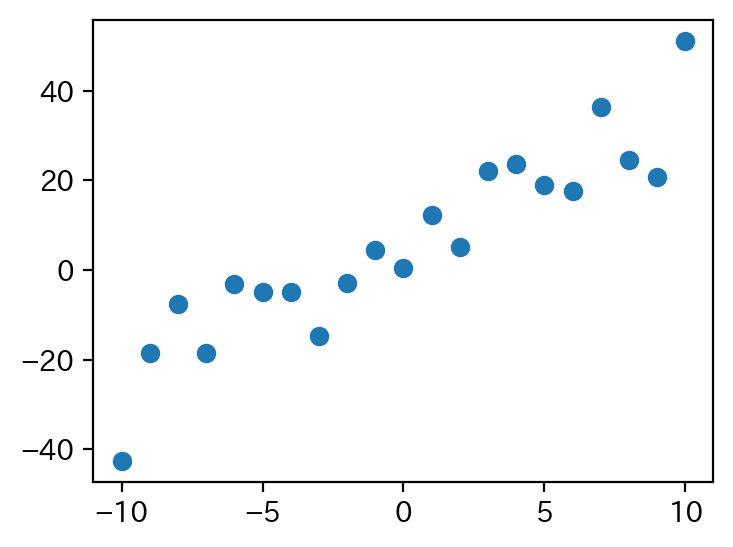

In [46]:
plt.figure(figsize=(4,3))
plt.scatter(df['xdata'], df['ydata'])
plt.show()

In [47]:
# 単回帰（線形回帰）
res = ols("ydata ~ xdata", data=df).fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  ydata   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     103.0
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           4.15e-09
Time:                        16:33:17   Log-Likelihood:                -73.959
No. Observations:                  21   AIC:                             151.9
Df Residuals:                      19   BIC:                             154.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.7359      1.879      3.053      0.007       1.803       9.669
xdata          3.1490      0.310     10.148      0.000       2.500       3.798
==============================================================================
Omnibus:                        0.708   Durbin-Watson:                   2.062
Prob(Omnibus):                  0.702   Jarque-Bera (JB):                0.722
Skew:                          -0.229   Prob(JB):                        0.697
Kurtosis:                       2.215   Cond. No.                         6.06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [48]:
a = res.params['xdata']
b = res.params['Intercept']
a, b

(np.float64(3.1490173453417354), np.float64(5.735892649077734))

In [49]:
# 回帰(regression)直線の準備
y_reg = (lambda x: a*x + b)(df_ice['気温'])
print(y_reg)

0      86.980540
1      82.571916
2      75.014274
3      81.627211
4      86.665638
         ...    
57     96.112690
58     98.002101
59    101.466020
60    102.410725
61    103.670332
Name: 気温, Length: 62, dtype: float64


In [50]:
x=np.array([-10, 10])
y = (lambda x: a*x + b)(x)
y

array([-25.7542808,  37.2260661])

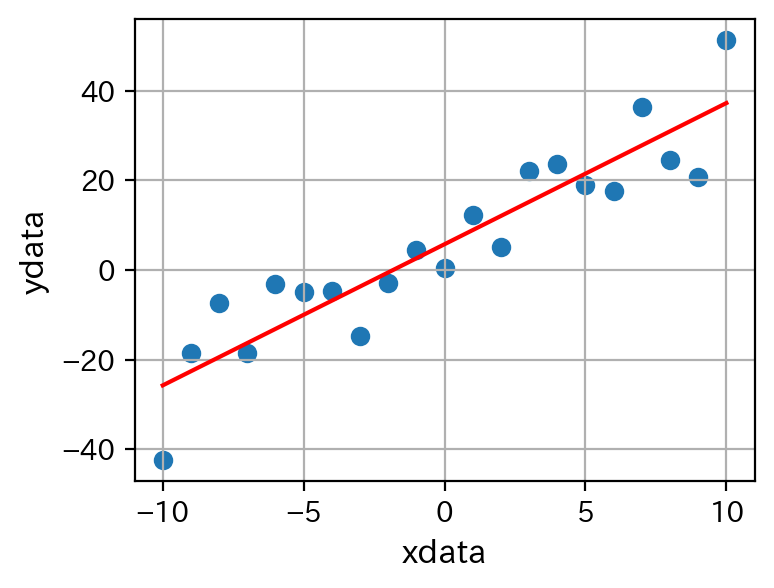

In [51]:
# 散布図の作成
plt.figure(figsize=(4,3))
plt.scatter(df['xdata'], df['ydata'])

# 傾きと切片の値を使った回帰直線描画
plt.plot(x, y, 'r-')

# 諸設定
plt.xlabel('xdata', fontsize=12)
plt.ylabel('ydata', fontsize=12)
plt.grid()
plt.show()

In [52]:
# 単回帰（線形回帰：原点強制通過）
res = ols("ydata ~ 0 + xdata", data=df).fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  ydata   R-squared (uncentered):                   0.784
Model:                            OLS   Adj. R-squared (uncentered):              0.774
Method:                 Least Squares   F-statistic:                              72.73
Date:                Mon, 24 Nov 2025   Prob (F-statistic):                    4.28e-08
Time:                        16:33:17   Log-Likelihood:                         -78.150
No. Observations:                  21   AIC:                                      158.3
Df Residuals:                      20   BIC:                                      159.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
xdata          3.1490      0.369      8.528      0.000       2.379       3.919
==============================================================================
Omnibus:                        0.708   Durbin-Watson:                   1.383
Prob(Omnibus):                  0.702   Jarque-Bera (JB):                0.722
Skew:                          -0.229   Prob(JB):                        0.697
Kurtosis:                       2.215   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [53]:
a = res.params['xdata']

x=np.array([-10, 10])
y = (lambda x: a*x)(x)
y

array([-31.49017345,  31.49017345])

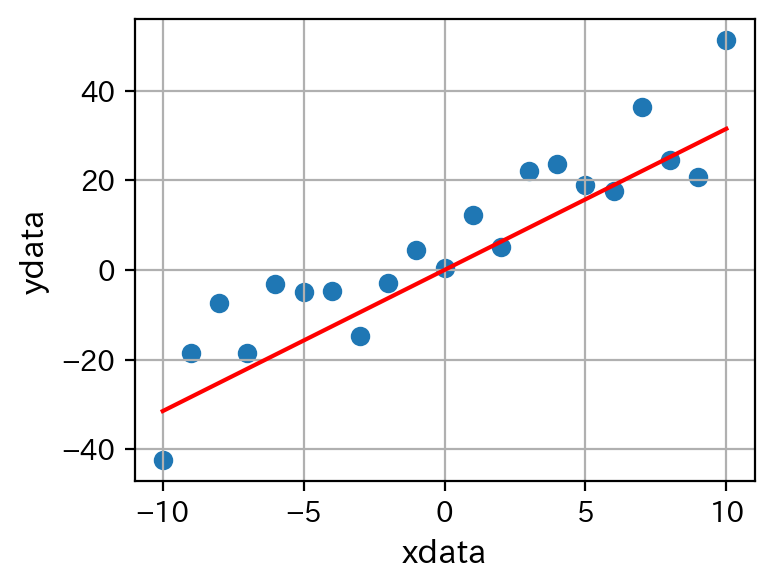

In [54]:
# 散布図の作成
plt.figure(figsize=(4,3))
plt.scatter(df['xdata'], df['ydata'])

# 傾きと切片の値を使った回帰直線描画
plt.plot(x, y, 'r-')

# 諸設定
plt.xlabel('xdata', fontsize=12)
plt.ylabel('ydata', fontsize=12)
plt.grid()
plt.show()